# 🎬 Sprint 2 — Demo Notebook
---


---
## 1. Setup

In [1]:
!pip install ultralytics easyocr opencv-python-headless

  Using cached ultralytics-8.4.40-py3-none-any.whl.metadata (39 kB)
  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached polars-1.40.0-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached python_bidi-0.6.7-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
  Using cached shapely-2.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
  Using cached pyclipper-1.4.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (8.6 kB)
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using c

In [2]:
# ======================================================================
# 1.1 — Imports
# ======================================================================
import os, sys, time, json, random
import numpy as np
import cv2
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

random.seed(42); np.random.seed(42)
print('✅ Imports')

✅ Imports


In [3]:
# ======================================================================
# 1.2 — EFS paths (ACTUAL repo structure)
# ======================================================================
_C = [Path('/home/sagemaker-user/user-default-efs'), Path.home()/'user-default-efs']
EFS = next((c for c in _C if (c/'IronGear').exists()), _C[0])
IRONGEAR = EFS / 'IronGear'

IMG_EXTS = {'.png', '.jpg', '.jpeg'}

# Sprint 2 model (transferred from Kaggle via Git LFS)
MODEL_PATH  = IRONGEAR / 'Sprint2' / 'models' / 'best.pt'
# Sprint 1 model (for comparison)
S1_MODEL    = IRONGEAR / 'Sprint1-POC' / 'models' / 'sprint1_yolo11x' / 'weights' / 'best.pt'
# Dataset
TEST_DIR    = IRONGEAR / 'data' / 'yolo_dataset' / 'images' / 'test'
TEST_LABELS = IRONGEAR / 'data' / 'yolo_dataset' / 'labels' / 'test'
SPRINT2_DIR = IRONGEAR / 'Sprint2'

print(f'IronGear: {IRONGEAR}')
print(f'Model:    {MODEL_PATH}')
print(f'Test dir: {TEST_DIR}')

IronGear: /home/sagemaker-user/user-default-efs/IronGear
Model:    /home/sagemaker-user/user-default-efs/IronGear/Sprint2/models/best.pt
Test dir: /home/sagemaker-user/user-default-efs/IronGear/data/yolo_dataset/images/test


In [4]:
# ======================================================================
# 1.3 — Model assertion (CRITICAL)
# ======================================================================
assert MODEL_PATH.exists(), (
    f'❌ Sprint 2 model not found at {MODEL_PATH}\n'
    f'   Run: cd {IRONGEAR} && git pull origin main && git lfs pull'
)
sz = MODEL_PATH.stat().st_size / 1e6
assert sz > 50, f'❌ File is {sz:.1f} MB — probably a LFS pointer. Run git lfs pull'
print(f'✅ Model: {MODEL_PATH.name} ({sz:.1f} MB)')

✅ Model: best.pt (51.2 MB)


In [5]:
# ======================================================================
# 1.4 — Load YOLO + EasyOCR + utils
# ======================================================================
from ultralytics import YOLO
model = YOLO(str(MODEL_PATH))
CLASS_NAMES = model.names
print(f'✅ YOLO: {CLASS_NAMES}')

# Import Sprint 2 utils (ocr.py, report.py)
sys.path.insert(0, str(SPRINT2_DIR))
from utils.ocr import LateralityExtractor
from utils.report import generate_report, format_report_text
extractor = LateralityExtractor()
print('✅ EasyOCR + report modules loaded')

✅ YOLO: {0: 'fracture', 1: 'metal_implant', 2: 'periosteal_reaction', 3: 'pronator_sign', 4: 'text'}
✅ EasyOCR reader initialised (CPU mode)
✅ EasyOCR + report modules loaded


---
## 2. Test Sample Selection (30 Stratified)

In [6]:
# ======================================================================
# 2.1 — Select 30 stratified samples
# ======================================================================
all_test = [p for p in TEST_DIR.glob('*')
            if p.suffix.lower() in IMG_EXTS and '_os' not in p.stem]
print(f'Total test images: {len(all_test):,}')

# Group by class
groups = {i: [] for i in range(5)}
negatives = []
for ip in all_test:
    lf = TEST_LABELS / f'{ip.stem}.txt'
    if not lf.exists(): negatives.append(ip); continue
    with open(lf) as f:
        cids = {int(l.split()[0]) for l in f if len(l.split())>=5}
    if not cids: negatives.append(ip)
    else:
        for c in cids:
            if c in groups: groups[c].append(ip)

sel = set()
for cid in range(5):
    pool = [p for p in groups[cid] if p not in sel]
    sel.update(random.sample(pool, min(5, len(pool))))
rem = 30 - len(sel)
if rem > 0:
    pool = [p for p in negatives if p not in sel]
    sel.update(random.sample(pool, min(rem, len(pool))))
rem = 30 - len(sel)
if rem > 0:
    pool = [p for p in all_test if p not in sel]
    sel.update(random.sample(pool, min(rem, len(pool))))

samples = sorted(list(sel))
print(f'✅ Selected {len(samples)} samples')

Total test images: 3,115
✅ Selected 30 samples


---
## 3. Inference Loop

In [7]:
# ======================================================================
# 3.1 — Run inference on all samples
# ======================================================================
CONF = 0.42
log = []

for i, ip in enumerate(samples):
    t0 = time.time()
    img = cv2.imread(str(ip), cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"  ⚠️ Unreadable: {ip.name}")
        continue
    
    # GRAZPEDWRI-DX is 16-bit grayscale — convert to 8-bit for OCR compatibility
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Ensure 3-channel BGR for EasyOCR (it handles grayscale but 3-channel is safer)
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    h, w = img.shape[:2]
    yr = model(str(ip), conf=CONF, verbose=False)[0]
    

    dets = []
    for b in yr.boxes:
        cid = int(b.cls[0]); conf = float(b.conf[0])
        xy = b.xyxy[0].cpu().numpy()
        dets.append({'class_id':cid, 'class_name':CLASS_NAMES.get(cid,''),
                     'confidence':conf, 'box':[xy[0]/w,xy[1]/h,xy[2]/w,xy[3]/h]})

    lat, raw = extractor.extract_from_detections(img, dets, text_class_id=4)
    ms = (time.time()-t0)*1000
    report = generate_report(dets, lat, raw, CONF, ms)

    # Compare with GT
    lf = TEST_LABELS / f'{ip.stem}.txt'
    gt = set()
    if lf.exists():
        with open(lf) as f: gt = {int(l.split()[0]) for l in f if len(l.split())>=5}
    gt_clin = gt - {4}
    pred_clin = {d['class_id'] for d in dets if d['class_id']!=4 and d['confidence']>=CONF}
    # Save annotated image for the top-findings cases
    if dets:  # only save images with detections
        annotated = yr.plot()
        annotated_dir = SPRINT2_DIR / 'demo_outputs' / 'annotated'
        annotated_dir.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(annotated_dir / f'{ip.stem}_annotated.png'), annotated)
    if not gt_clin and not pred_clin: cat = 'NEGATIVE'
    elif gt_clin == pred_clin: cat = 'CORRECT'
    elif gt_clin and not pred_clin: cat = 'MISSED'
    elif pred_clin - gt_clin: cat = 'FALSE_POS'
    else: cat = 'PARTIAL'

    log.append({'image':ip.name, 'cat':cat, 'report':report, 'ms':ms})
    if (i+1)%10==0 or i==0:
        print(f'  [{i+1}/{len(samples)}] {ip.name}: {cat} ({ms:.0f}ms)')

cats = Counter(r['cat'] for r in log)
print(f'\n✅ Done. ' + '  '.join(f'{k}:{v}' for k,v in sorted(cats.items())))

  [1/30] 0078_1212376663_01_WRI-L2_M011.png: CORRECT (2940ms)
  [10/30] 2513_1107095112_01_WRI-L2_F009.png: NEGATIVE (45ms)
  [20/30] 4029_1085481693_05_WRI-R1_M015.png: CORRECT (163ms)
  [30/30] 6002_0324826200_05_WRI-L2_F006.png: FALSE_POS (178ms)

✅ Done. CORRECT:23  FALSE_POS:2  NEGATIVE:4  PARTIAL:1


---
## 4. Report Showcase (3 Cases)

In [9]:
# ======================================================================
# 4.1 — Find & print representative cases
# ======================================================================
def find(cat, cls=None, minf=None):
    for r in log:
        if r['cat']!=cat: continue
        fd = r['report']['findings_detected']
        if cls and not any(f['class_name']==cls for f in fd): continue
        if minf and len(fd)<minf: continue
        return r
    return None

for label, case in [
    ('A: Fracture', find('CORRECT',cls='fracture') or find('PARTIAL',cls='fracture')),
    ('B: Multi-finding', find('CORRECT',minf=2) or find('PARTIAL',minf=2)),
    ('C: Negative', find('NEGATIVE')),
]:
    print(f'\n{"="*60}\n  Case {label}')
    if case:
        print(f'  Image: {case["image"]}')
        print(format_report_text(case['report']))
    else:
        print('  ⚠️ No matching case found')


  Case A: Fracture
  Image: 0078_1212376663_01_WRI-L2_M011.png
  WRISTASSIST AI — CLINICAL REPORT
  Request ID:    11af9b19-9a54-41fc-aebd-a4f2f3bc928d
  Model:         sprint2_yolo11l_expB_v1
  Timestamp:     2026-04-21T10:03:06.205589+00:00
  Laterality:    Unknown
  Latency:       2939.9 ms
  Threshold:     0.42

  FINDINGS DETECTED:
    • fracture                  conf=0.766  box=[np.float32(0.3685), np.float32(0.4012), np.float32(0.5209), np.float32(0.4602)]

  NOT DETECTED (no findings):
    • metal_implant
    • periosteal_reaction
    • pronator_sign

  SUMMARY FLAGS:
    🔴 fracture_suspected: True
    🟢 implant_present: False
    🟢 periosteal_reaction_present: False
    🟢 pronator_sign_present: False
    🟢 needs_human_review: False

  Case B: Multi-finding
  Image: 0147_0255030249_02_WRI-L1_M010.png
  WRISTASSIST AI — CLINICAL REPORT
  Request ID:    1d4f7b1d-f9c1-4de2-891e-dd79c32930ea
  Model:         sprint2_yolo11l_expB_v1
  Timestamp:     2026-04-21T10:03:06.440067+00:00

---
## 5. Sprint 1 vs Sprint 2 Comparison

In [10]:
# ======================================================================
# 5.1 — Comparison
# ======================================================================
ej = SPRINT2_DIR / 'eval_summary.json'
if ej.exists():
    with open(ej) as f: s2 = json.load(f)
    s2ap = s2.get('per_class_ap50',{})
else:
    print('⚠️ eval_summary.json not found'); s2ap = {}; s2 = {'map50':0}

S1 = {'fracture':0.939,'metal_implant':0.865,'periosteal_reaction':0.649,'pronator_sign':0.665}

print('='*65)
print('  SPRINT 1 vs SPRINT 2')
print('='*65)
print(f'{"Metric":<28} {"S1":>8} {"S2":>8} {"Delta":>8}')
print('-'*65)
print(f'{"mAP@0.5":<28} {0.685:>8.4f} {s2.get("map50",0):>8.4f} {s2.get("map50",0)-0.685:>+8.4f}')
for n in ['fracture','metal_implant','periosteal_reaction','pronator_sign']:
    v1, v2 = S1.get(n,0), s2ap.get(n,0)
    print(f'{n+" AP":<28} {v1:>8.4f} {v2:>8.4f} {v2-v1:>+8.4f}')
print(f'{"text AP":<28} {"N/A":>8} {s2ap.get("text",0):>8.4f} {"NEW":>8}')
print('\n  New: EasyOCR laterality, JSON reports, ClearML tracking, auto gate')

  SPRINT 1 vs SPRINT 2
Metric                             S1       S2    Delta
-----------------------------------------------------------------
mAP@0.5                        0.6850   0.8423  +0.1573
fracture AP                    0.9390   0.9412  +0.0022
metal_implant AP               0.8650   0.9062  +0.0412
periosteal_reaction AP         0.6490   0.6951  +0.0461
pronator_sign AP               0.6650   0.6780  +0.0130
text AP                           N/A   0.9908      NEW

  New: EasyOCR laterality, JSON reports, ClearML tracking, auto gate


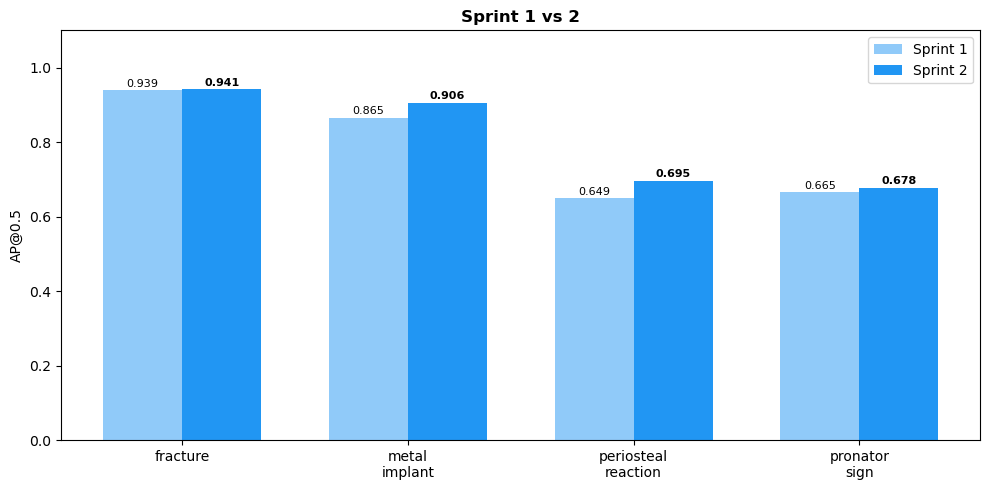

In [11]:
# ======================================================================
# 5.2 — Bar chart
# ======================================================================
fig, ax = plt.subplots(figsize=(10,5))
cls = ['fracture','metal_implant','periosteal_reaction','pronator_sign']
x = np.arange(len(cls)); w = 0.35
v1 = [S1[c] for c in cls]; v2 = [s2ap.get(c,0) for c in cls]
ax.bar(x-w/2, v1, w, label='Sprint 1', color='#90CAF9')
ax.bar(x+w/2, v2, w, label='Sprint 2', color='#2196F3')
for xi, vi in zip(x, v1): ax.text(xi-w/2, vi+.01, f'{vi:.3f}', ha='center', fontsize=8)
for xi, vi in zip(x, v2): ax.text(xi+w/2, vi+.01, f'{vi:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_','\n') for c in cls])
ax.set_ylabel('AP@0.5'); ax.set_title('Sprint 1 vs 2', fontweight='bold')
ax.legend(); ax.set_ylim(0,1.1)
plt.tight_layout()
plt.savefig(SPRINT2_DIR/'figures'/'s1_vs_s2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Interactive Upload Widget

In [12]:
# ======================================================================
# 6.1 — Upload widget
# ======================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

up = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
out = widgets.Output()

def get_bytes(w):
    v = w.value
    fi = list(v.values())[0] if isinstance(v,dict) else v[0]
    return fi['content'] if isinstance(fi,dict) else fi

def on_up(change):
    with out:
        clear_output()
        try:
            raw = get_bytes(up)
            img = cv2.imdecode(np.frombuffer(raw, np.uint8), cv2.IMREAD_UNCHANGED)
            if img is None:
                print("❌ Could not decode uploaded image")
                return
            
            if img.dtype != np.uint8:
                img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            
            h, w2 = img.shape[:2]
            
            # GRAZPEDWRI-DX is 16-bit grayscale — convert to 8-bit for OCR compatibility
            if img.dtype != np.uint8:
                img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            
            # Ensure 3-channel BGR for EasyOCR (it handles grayscale but 3-channel is safer)
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            
            h, w = img.shape[:2]
            t0 = time.time()
            yr = model(img, conf=CONF, verbose=False)[0]
            ds = [{'class_id':int(b.cls[0]),'class_name':CLASS_NAMES.get(int(b.cls[0]),''),
                   'confidence':float(b.conf[0]),
                   'box':[float(b.xyxy[0][j])/([w2,h,w2,h][j]) for j in range(4)]}
                  for b in yr.boxes]
            la, rt = extractor.extract_from_detections(img, ds, 4)
            rp = generate_report(ds, la, rt, CONF, (time.time()-t0)*1000)
            plt.figure(figsize=(10,8))
            plt.imshow(cv2.cvtColor(yr.plot(), cv2.COLOR_BGR2RGB))
            plt.title(f'Laterality: {la} | {rp["latency_ms"]:.0f}ms'); plt.axis('off')
            plt.show()
            print(format_report_text(rp))
        except Exception as e: print(f'❌ {e}')

up.observe(on_up, names='value')
display(widgets.VBox([up, out]))
print('👆 Upload an X-ray')

👆 Upload an X-ray


---
## 7. Summary

In [13]:
# ======================================================================
# 7.1 — Summary table
# ======================================================================
cats = Counter(r['cat'] for r in log)
avg_ms = np.mean([r['ms'] for r in log])
lat_c = Counter(r['report']['laterality'] for r in log)

print('='*50)
print('  SPRINT 2 DEMO SUMMARY')
print('='*50)
print(f'  Samples: {len(log)}  |  Avg latency: {avg_ms:.0f}ms  |  Threshold: {CONF}')
for c in ['CORRECT','PARTIAL','MISSED','FALSE_POS','NEGATIVE']:
    n = cats.get(c,0); p = n/len(log)*100
    print(f'    {c:<12} {n:>3} ({p:>5.1f}%) {"█"*int(p/5)}')
print(f'  Laterality: {dict(lat_c)}')
print('='*50)

  SPRINT 2 DEMO SUMMARY
  Samples: 30  |  Avg latency: 237ms  |  Threshold: 0.42
    CORRECT       23 ( 76.7%) ███████████████
    PARTIAL        1 (  3.3%) 
    MISSED         0 (  0.0%) 
    FALSE_POS      2 (  6.7%) █
    NEGATIVE       4 ( 13.3%) ██
  Laterality: {'Unknown': 15, 'Left': 4, 'Right': 11}


---
## ✅ Demo Complete

**SCRUM-35** ✅ Sprint 2 demo notebook  

Demonstrated: 5-class YOLO, EasyOCR laterality, JSON reports, S1 vs S2 comparison, upload widget.